# Taller de movilidad urbana: taxis y clima en Nueva York

**Caso de estudio:** viajes de NYC TLC Yellow Taxi durante enero de 2024.

En este taller construiremos un flujo reproducible: adquisición, inspección, auditoría de calidad, enriquecimiento por zonas, agregación temporal, integración con clima y análisis exploratorio. No buscamos demostrar causalidad, sino aprender a formular y comprobar preguntas con datos reales.

## Objetivos

Al finalizar podrás:

- construir y validar una URL de datos abiertos;
- inspeccionar estructura, tipos y faltantes antes de analizar;
- convertir reglas de calidad en una tabla de auditoría;
- enriquecer viajes mediante uniones `many_to_one`;
- agregar pickups por zona y hora sin sesgar la serie temporal;
- convertir observaciones meteorológicas de UTC a `America/New_York`;
- comunicar patrones y límites de un análisis exploratorio.

> **Pregunta guía:** ¿cómo varían los pickups de Yellow Taxi por lugar y hora, y qué relación exploratoria muestran con temperatura y precipitación?

## Ficha de fuentes

| Fuente | Recurso usado | Papel en el taller |
|---|---|---|
| [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Yellow Taxi, enero de 2024 (`yellow_tripdata_2024-01.parquet`) | fecha/hora, zonas, distancia, pasajeros e importes de viajes reportados |
| NYC TLC | [Taxi Zone Lookup](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv) | traduce `LocationID` a borough, zona y `service_zone` |
| NYC TLC | [Taxi Zone Shapefile](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip) | geometrías para la extensión espacial opcional |
| [NOAA GHCNh](https://www.ncei.noaa.gov/products/global-historical-climatology-network-hourly) | estación `USW00094728`, año 2024 | observaciones de clima con marcas temporales UTC |

**Periodo común:** enero de 2024 en hora local de Nueva York. Los archivos se leen desde sus URL o desde un directorio temporal; este notebook no guarda datasets en el repositorio. Consulta la documentación y licencias de cada proveedor antes de reutilizar los datos.

## 1. Preparación y modo de ejecución

En Colab normalmente basta con ejecutar los imports. Si falta el motor Parquet, descomenta la instalación. La extensión espacial se instala solo si se desea ejecutar esa sección.

In [ ]:
# Instalación opcional para Google Colab/Jupyter (descomentar si hace falta):
# %pip install -q pyarrow
# %pip install -q geopandas folium requests

from io import StringIO
import tempfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
# True: primera semana de enero; False: todo enero. No hay muestreo aleatorio.
MODO_CLASE = False
INICIO_MES = pd.Timestamp("2024-01-01")
FIN_MES = pd.Timestamp("2024-02-01")
FIN_ANALISIS = pd.Timestamp("2024-01-08") if MODO_CLASE else FIN_MES
ZONA_HORARIA = "America/New_York"

print(f"Ventana: {INICIO_MES} hasta {FIN_ANALISIS} (fin no incluido)")

Ventana: 2024-01-01 00:00:00 hasta 2024-02-01 00:00:00 (fin no incluido)


`MODO_CLASE` limita la lectura mediante un filtro temporal de Parquet cuando el motor lo permite. La selección es una semana completa y determinista, no una muestra aleatoria: así preservamos horas consecutivas y el flujo de agregación. En modo completo, la misma lógica procesa todo enero.

## 2. URL validada y carga reproducible

In [ ]:
def construir_url_tlc(tipo, anio, mes):
    """Construye una URL TLC válida para un tipo, año y mes."""
    prefijos = {
        "yellow": "yellow_tripdata",
        "green": "green_tripdata",
        "fhv": "fhv_tripdata",
        "fhvhv": "fhvhv_tripdata",
    }
    if tipo not in prefijos:
        opciones = ", ".join(prefijos)
        raise ValueError(f"tipo debe ser uno de: {opciones}")
    if isinstance(anio, bool) or not isinstance(anio, (int, np.integer)) or not 2009 <= anio <= 2100:
        raise ValueError("anio debe ser un entero entre 2009 y 2100")
    if isinstance(mes, bool) or not isinstance(mes, (int, np.integer)) or not 1 <= mes <= 12:
        raise ValueError("mes debe ser un entero entre 1 y 12")
    archivo = f"{prefijos[tipo]}_{anio}-{mes:02d}.parquet"
    return f"https://d37ci6vzurychx.cloudfront.net/trip-data/{archivo}"

URL_VIAJES = construir_url_tlc("yellow", 2024, 1)
URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
URL_GEOMETRIAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
URL_CLIMA = (
    "https://www.ncei.noaa.gov/oa/global-historical-climatology-network/"
    "hourly/access/by-year/2024/psv/GHCNh_USW00094728_2024.psv"
)
print(URL_VIAJES)

https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


In [ ]:
COLUMNAS_VIAJES = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "PULocationID",
    "DOLocationID", "fare_amount", "total_amount",
]
filtros = [
    ("tpep_pickup_datetime", ">=", INICIO_MES.to_pydatetime()),
    ("tpep_pickup_datetime", "<", FIN_ANALISIS.to_pydatetime()),
]

# PyArrow aplica el filtro por fecha al leer los grupos de filas compatibles.
viajes_originales = pd.read_parquet(
    URL_VIAJES, columns=COLUMNAS_VIAJES, filters=filtros, engine="pyarrow"
)
print(f"Viajes cargados: {len(viajes_originales):,}")

Viajes cargados: 2,964,606


### Pregunta breve

¿Por qué una semana consecutiva es preferible a una muestra aleatoria si queremos comparar horas y días? Escribe una hipótesis antes de continuar.

<details><summary>Ver respuesta orientativa</summary>Una muestra aleatoria puede dejar horas incompletas y alterar sus conteos. Una ventana consecutiva conserva el orden, los ciclos diarios y el denominador temporal, aunque no necesariamente representa el mes completo.</details>

## 3. Inspección antes de limpiar

No debemos decidir reglas sin conocer el esquema. Observa dimensiones, ejemplos, tipos y faltantes.

In [ ]:
print("Shape:", viajes_originales.shape)
display(viajes_originales.head())
print("\nInfo:")
viajes_originales.info()
print("\nTipos:")
display(viajes_originales.dtypes.rename("dtype").to_frame())

faltantes = (
    viajes_originales.isna().sum().rename("n_faltantes").to_frame()
    .assign(porcentaje=lambda x: 100 * x["n_faltantes"] / len(viajes_originales))
    .sort_values("porcentaje", ascending=False)
)
display(faltantes)

Shape: (2964606, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,17.7,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,10.0,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,23.3,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,10.0,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,7.9,16.10



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964606 entries, 0 to 2964605
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(4), int32(2)
memory usage: 158.3 MB

Tipos:


,dtype
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
PULocationID,int32
DOLocationID,int32
fare_amount,float64
total_amount,float64


,n_faltantes,porcentaje
passenger_count,140162,4.727846
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
trip_distance,0,0.000000
PULocationID,0,0.000000
DOLocationID,0,0.000000
fare_amount,0,0.000000
total_amount,0,0.000000


**Observa:** `passenger_count` puede faltar por la forma de reporte. Su ausencia se conserva y no invalida automáticamente un viaje. Solo marcaremos como problemáticos los valores presentes fuera de un intervalo operativo razonable.

## 4. Calidad y auditoría

Las reglas siguientes son criterios analíticos, no verdades universales. Distancia máxima de 100 millas, hasta 8 pasajeros e importes menores a USD 1,000 son umbrales conservadores para detectar registros extremos o inválidos. Cada regla queda en una columna booleana.

In [ ]:
calidad = viajes_originales.copy()
calidad["duracion_min"] = (
    calidad["tpep_dropoff_datetime"] - calidad["tpep_pickup_datetime"]
).dt.total_seconds() / 60

calidad["ok_pickup"] = calidad["tpep_pickup_datetime"].notna() & calidad["tpep_pickup_datetime"].between(INICIO_MES, FIN_ANALISIS, inclusive="left")
calidad["ok_dropoff"] = calidad["tpep_dropoff_datetime"].notna()
calidad["ok_duracion"] = calidad["duracion_min"].gt(0) & calidad["duracion_min"].le(24 * 60)
calidad["ok_distancia"] = calidad["trip_distance"].between(0, 100, inclusive="both")
calidad["ok_id_pickup_presente"] = calidad["PULocationID"].notna()
calidad["ok_id_dropoff_presente"] = calidad["DOLocationID"].notna()
calidad["ok_importes"] = (
    calidad["fare_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].ge(calidad["fare_amount"])
)
calidad["ok_pasajeros"] = calidad["passenger_count"].isna() | calidad["passenger_count"].between(0, 8, inclusive="both")

REGLAS = [c for c in calidad.columns if c.startswith("ok_")]
calidad["registro_valido"] = calidad[REGLAS].all(axis=1)
auditoria = pd.DataFrame({
    "regla": REGLAS,
    "cumplen": [int(calidad[c].sum()) for c in REGLAS],
    "incumplen": [int((~calidad[c]).sum()) for c in REGLAS],
})
auditoria["porcentaje_incumple"] = 100 * auditoria["incumplen"] / len(calidad)
display(auditoria.sort_values("porcentaje_incumple", ascending=False))

,regla,cumplen,incumplen,porcentaje_incumple
6,ok_importes,2927032,37574,1.267420
2,ok_duracion,2963720,886,0.029886
3,ok_distancia,2964547,59,0.001990
7,ok_pasajeros,2964605,1,0.000034
0,ok_pickup,2964606,0,0.000000
1,ok_dropoff,2964606,0,0.000000
5,ok_id_dropoff_presente,2964606,0,0.000000
4,ok_id_pickup_presente,2964606,0,0.000000


In [ ]:
# Se mantienen por separado para no borrar silenciosamente información.
viajes_rechazados = calidad.loc[~calidad["registro_valido"]].copy()
viajes_validos = calidad.loc[calidad["registro_valido"]].copy()
print(f"Válidos: {len(viajes_validos):,} | Rechazados: {len(viajes_rechazados):,}")
display(viajes_rechazados[COLUMNAS_VIAJES + ["duracion_min"] + REGLAS].head())

Válidos: 2,926,101 | Rechazados: 38,505


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,duracion_min,ok_pickup,ok_dropoff,ok_duracion,ok_distancia,ok_id_pickup_presente,ok_id_dropoff_presente,ok_importes,ok_pasajeros
23,2024-01-01 00:14:29,2024-01-01 00:14:29,1.0,0.00,236,264,3.0,8.00,0.000000,True,True,False,True,True,True,True,True
99,2024-01-01 00:18:24,2024-01-01 00:30:39,1.0,2.16,249,232,-13.5,-18.50,12.250000,True,True,True,True,True,True,False,True
504,2024-01-01 00:04:00,2024-01-01 00:04:44,1.0,0.01,63,63,-31.5,-34.25,0.733333,True,True,True,True,True,True,False,True
534,2024-01-01 00:41:42,2024-01-01 00:46:00,1.0,0.47,249,113,-5.8,-10.80,4.300000,True,True,True,True,True,True,False,True
550,2024-01-01 00:42:02,2024-01-01 01:14:33,1.0,5.48,107,61,-33.1,-38.10,32.516667,True,True,True,True,True,True,False,True


### Ejercicio 1: sensibilidad de una regla

Calcula cuántos viajes quedarían fuera si la distancia máxima fuese 50 millas, sin modificar `viajes_validos`.

In [ ]:
# Tu respuesta:
# fuera_con_umbral_50 = ...

<details><summary>Ver solución</summary>

```python
fuera_con_umbral_50 = (~calidad["trip_distance"].between(0, 50)).sum()
print(fuera_con_umbral_50)
```

Conviene comparar este resultado con `ok_distancia` y justificar el umbral con conocimiento del dominio.
</details>

## 5. Enriquecimiento con zonas

### Objetivo

La tabla de viajes identifica el origen mediante `PULocationID` y el destino mediante `DOLocationID`. Estos códigos son útiles para relacionar tablas, pero no permiten interpretar directamente dónde comenzó o terminó un viaje.

En esta sección agregaremos a cada viaje el nombre de la zona, el borough y la clasificación de servicio tanto del origen como del destino. Conceptualmente:

```text
PULocationID = 161
        ↓
pickup_zone = Midtown Center
pickup_borough = Manhattan
pickup_service_zone = Yellow Zone
```

El enriquecimiento no cambia la unidad de observación: cada fila continúa representando un viaje Yellow Taxi reportado. Solo agrega contexto geográfico a sus identificadores.

### 5.1. El catálogo de zonas

`taxi_zone_lookup.csv` es un **catálogo de correspondencias** publicado por NYC TLC. No contiene viajes: contiene una descripción por `LocationID`.

| Columna | Significado |
|---|---|
| `LocationID` | Identificador numérico de la zona TLC |
| `Borough` | Distrito amplio, como Manhattan, Queens o Brooklyn |
| `Zone` | Nombre específico de la zona TLC |
| `service_zone` | Clasificación operativa, como `Yellow Zone`, `Boro Zone` o `Airports` |

Para que el catálogo pueda representar el lado **uno** de una unión, `LocationID` debe ser único.

In [ ]:
zonas = pd.read_csv(URL_ZONAS)
display(zonas.head())
print("Cantidad de zonas:", len(zonas))
print("LocationID es único:", zonas["LocationID"].is_unique)

if zonas["LocationID"].duplicated().any():
    raise ValueError("Taxi Zone Lookup contiene LocationID duplicados")

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Cantidad de zonas: 265
LocationID es único: True


### 5.2. Un catálogo, dos roles

Cada viaje consulta el mismo catálogo desde dos papeles diferentes:

```text
PULocationID → zona de origen o pickup
DOLocationID → zona de destino o dropoff
```

Por eso creamos `zonas_pickup` y `zonas_dropoff`. No son dos catálogos distintos ni duplican los viajes: son dos versiones del mismo catálogo con nombres que explicitan el rol de sus columnas.

| Origen | Destino |
|---|---|
| `pickup_zone` | `dropoff_zone` |
| `pickup_borough` | `dropoff_borough` |
| `pickup_service_zone` | `dropoff_service_zone` |

Renombrar antes de unir evita nombres ambiguos como `Zone_x` y `Zone_y`. `DataFrame.rename()` devuelve estas versiones adaptadas sin modificar `zonas`.

In [ ]:
zonas_pickup = zonas.rename(columns={
    "LocationID": "PULocationID", "Borough": "pickup_borough",
    "Zone": "pickup_zone", "service_zone": "pickup_service_zone",
})
zonas_dropoff = zonas.rename(columns={
    "LocationID": "DOLocationID", "Borough": "dropoff_borough",
    "Zone": "dropoff_zone", "service_zone": "dropoff_service_zone",
})

display(zonas_pickup.head(2))
display(zonas_dropoff.head(2))

,PULocationID,pickup_borough,pickup_zone,pickup_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


### 5.3. Cardinalidad `many_to_one`

La relación esperada es **muchos viajes → una descripción de zona**. Un mismo `PULocationID` o `DOLocationID` puede aparecer en miles de viajes, pero cada identificador debe aparecer como máximo una vez en el catálogo correspondiente.

`validate="many_to_one"` hace que pandas compruebe esta condición durante la unión. Si el catálogo tuviera dos filas para `LocationID = 161`, tres viajes con ese identificador producirían seis filas:

```text
3 viajes × 2 coincidencias en el catálogo = 6 filas
```

Esa multiplicación inflaría conteos, importes, promedios y mapas. La validación detiene el proceso con un error en lugar de producir silenciosamente un resultado incorrecto. También ayuda a detectar catálogos repetidos, mezcla de versiones o descripciones contradictorias para un mismo ID.

### 5.4. Dos uniones izquierdas

Primero agregamos los atributos del origen y después los del destino. `how="left"` conserva todos los viajes válidos. Si un ID no aparece en el catálogo, el viaje permanece y sus atributos geográficos quedan como `NaN`, lo que permite auditar la falta de correspondencia en vez de eliminarla silenciosamente.

In [ ]:
viajes_zonas = (
    viajes_validos.merge(zonas_pickup, on="PULocationID", how="left", validate="many_to_one")
    .merge(zonas_dropoff, on="DOLocationID", how="left", validate="many_to_one")
)

### 5.5. Controles posteriores e interpretación

Después de unir comprobamos dos propiedades diferentes:

1. **Conservación de filas:** la cantidad de viajes no debe cambiar.
2. **Cobertura del catálogo:** contamos los viajes cuyo ID no encontró nombre de zona.

`many_to_one` no garantiza cobertura completa ni detecta viajes duplicados, IDs faltantes, nombres incorrectos en una fila única o el uso de la clave equivocada. Por eso se complementa con estos controles y con la revisión semántica de las columnas obtenidas.

In [ ]:
assert len(viajes_zonas) == len(viajes_validos), "La unión cambió el número de viajes"

sin_nombre_pickup = viajes_zonas["pickup_zone"].isna().sum()
sin_nombre_dropoff = viajes_zonas["dropoff_zone"].isna().sum()
print("Viajes antes y después:", len(viajes_validos), len(viajes_zonas))
print("Sin zona pickup:", sin_nombre_pickup, "| Sin zona dropoff:", sin_nombre_dropoff)

COLUMNAS_ZONA = [
    "PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone",
]
display(viajes_zonas[COLUMNAS_ZONA].head())

Viajes antes y después: 2926101 2926101
Sin zona pickup: 10177 | Sin zona dropoff: 15295


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,79,Manhattan,East Village,Yellow Zone
1,140,Manhattan,Lenox Hill East,Yellow Zone,236,Manhattan,Upper East Side North,Yellow Zone
2,236,Manhattan,Upper East Side North,Yellow Zone,79,Manhattan,East Village,Yellow Zone
3,79,Manhattan,East Village,Yellow Zone,211,Manhattan,SoHo,Yellow Zone
4,211,Manhattan,SoHo,Yellow Zone,148,Manhattan,Lower East Side,Yellow Zone


### Resultado de la sección

Cada fila sigue representando un viaje, pero ahora permite interpretar tanto su origen como su destino. Las zonas son áreas geográficas agregadas definidas por TLC: no indican una dirección ni una coordenada exacta, y el enriquecimiento no agrega demanda total, solicitudes no atendidas ni vehículos disponibles.

### Pregunta breve

¿Qué ocurriría si `LocationID = 161` apareciera dos veces en el catálogo y no utilizáramos `validate="many_to_one"`?

<details><summary>Ver respuesta orientativa</summary>Cada viaje con ese identificador encontraría dos coincidencias y aparecería dos veces en el resultado. Los conteos y agregaciones posteriores quedarían inflados. Con `validate="many_to_one"`, pandas detecta que el lado del catálogo no es único y detiene la unión.</details>

## 6. Agregación zona-hora de pickups

Los timestamps TLC se interpretan como hora local. En enero de 2024 no hay transición de horario de verano, pero explicitar la zona horaria evita una unión ambigua con NOAA.

In [ ]:
viajes_zonas["pickup_hora"] = (
    viajes_zonas["tpep_pickup_datetime"]
    .dt.tz_localize(ZONA_HORARIA, ambiguous="raise", nonexistent="raise")
    .dt.floor("h")
)
pickups_zona_hora = (
    viajes_zonas.groupby(
        ["pickup_hora", "PULocationID", "pickup_borough", "pickup_zone"],
        observed=True, dropna=False,
    )
    .size().rename("pickups").reset_index()
)
assert pickups_zona_hora.duplicated(["pickup_hora", "PULocationID"]).sum() == 0
display(pickups_zona_hora.head())

,pickup_hora,PULocationID,pickup_borough,pickup_zone,pickups
0,2024-01-01 00:00:00-05:00,4,Manhattan,Alphabet City,24
1,2024-01-01 00:00:00-05:00,7,Queens,Astoria,4
2,2024-01-01 00:00:00-05:00,9,Queens,Auburndale,1
3,2024-01-01 00:00:00-05:00,10,Queens,Baisley Park,6
4,2024-01-01 00:00:00-05:00,12,Manhattan,Battery Park,4


## 7. Clima: UTC, hora local y resumen horario

GHCNh puede contener varias observaciones dentro de una hora. Seleccionaremos variables numéricas, convertiremos valores no numéricos a faltantes y resumiremos a una fila por hora. Temperatura usa media; precipitación usa suma con `min_count=1` para no convertir una hora totalmente faltante en cero.

In [ ]:
COLUMNAS_CLIMA = [
    "STATION", "Station_name", "DATE", "temperature",
    "relative_humidity", "wind_speed", "precipitation", "visibility",
]
with urlopen(URL_CLIMA) as respuesta:
    texto_clima = respuesta.read().decode("utf-8")
clima_bruto = pd.read_csv(StringIO(texto_clima), sep="|", usecols=COLUMNAS_CLIMA, low_memory=False)
assert clima_bruto["STATION"].astype(str).eq("USW00094728").all()
print("Observaciones meteorológicas cargadas:", len(clima_bruto))

Observaciones meteorológicas cargadas: 11222


In [ ]:
clima = clima_bruto.copy()
clima["fecha_utc"] = pd.to_datetime(clima["DATE"], utc=True, errors="coerce")
clima["fecha_ny"] = clima["fecha_utc"].dt.tz_convert(ZONA_HORARIA)
inicio_local = INICIO_MES.tz_localize(ZONA_HORARIA)
fin_local = FIN_ANALISIS.tz_localize(ZONA_HORARIA)
clima = clima.loc[clima["fecha_ny"].between(inicio_local, fin_local, inclusive="left")].copy()

VARIABLES_CLIMA = ["temperature", "relative_humidity", "wind_speed", "precipitation", "visibility"]
clima[VARIABLES_CLIMA] = clima[VARIABLES_CLIMA].apply(pd.to_numeric, errors="coerce")
clima["hora"] = clima["fecha_ny"].dt.floor("h")
clima_horario = (
    clima.groupby("hora", as_index=False)
    .agg(
        temperatura_c=("temperature", "mean"),
        humedad_relativa=("relative_humidity", "mean"),
        viento=("wind_speed", "mean"),
        precipitacion_mm=("precipitation", lambda s: s.sum(min_count=1)),
        visibilidad=("visibility", "mean"),
        observaciones=("fecha_ny", "size"),
    )
)
if clima_horario["hora"].duplicated().any():
    raise ValueError("El resumen climático no es único por hora")
display(clima_horario.head())

,hora,temperatura_c,humedad_relativa,viento,precipitacion_mm,visibilidad,observaciones
0,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1
1,2024-01-01 01:00:00-05:00,5.6,58.0,2.1,0.0,16.093,1
2,2024-01-01 02:00:00-05:00,5.0,60.0,0.0,0.0,16.093,1
3,2024-01-01 03:00:00-05:00,5.0,62.0,1.5,0.0,16.093,1
4,2024-01-01 04:00:00-05:00,4.4,68.0,0.0,0.0,16.093,1


### Ejercicio 2: cobertura temporal

Compara las horas esperadas de la ventana con las horas observadas en `clima_horario`. ¿Hay huecos?

In [ ]:
# Tu respuesta:
# horas_esperadas = ...
# horas_sin_clima = ...

<details><summary>Ver solución</summary>

```python
horas_esperadas = pd.date_range(inicio_local, fin_local, freq="h", inclusive="left")
horas_sin_clima = horas_esperadas.difference(clima_horario["hora"])
print("Horas esperadas:", len(horas_esperadas))
print("Horas sin observación:", len(horas_sin_clima))
display(horas_sin_clima[:10])
```
</details>

## 8. Unión zona-hora con clima

Cada fila zona-hora debe encontrar como máximo una fila climática. La unión izquierda conserva los pickups aunque el clima falte.

In [ ]:
zona_hora_clima = pickups_zona_hora.merge(
    clima_horario, left_on="pickup_hora", right_on="hora",
    how="left", validate="many_to_one", indicator=True,
)
assert len(zona_hora_clima) == len(pickups_zona_hora), "La unión alteró la cardinalidad izquierda"
auditoria_union = zona_hora_clima["_merge"].value_counts(dropna=False).rename_axis("resultado").to_frame("filas")
display(auditoria_union)
zona_hora_clima = zona_hora_clima.drop(columns="_merge")

,filas
resultado,
both,77335
left_only,131
right_only,0


### ¿Por qué el clima queda repetido por zona?

La unidad de `zona_hora_clima` es **una zona en una hora**. En cambio, `clima_horario` contiene una sola observación por hora. Cuando esa observación se une con varias zonas de la misma hora, pandas la copia en cada fila zona-hora.

Ejemplo conceptual:

| zona | hora | pickups | temperatura |
|---|---|---:|---:|
| A | 08:00 | 20 | 5 °C |
| B | 08:00 | 35 | 5 °C |
| C | 08:00 | 15 | 5 °C |

Los tres valores de `5 °C` no son mediciones diferentes: son la misma observación meteorológica replicada por la unión `many_to_one`. Esta repetición es intencional, no un duplicado accidental. Además, NOAA representa una estación meteorológica; no estamos estimando un clima diferente para cada zona.

## 9. Análisis exploratorio con pandas y matplotlib

Lee cada gráfico como evidencia descriptiva. Pregunta siempre: ¿qué unidad representa?, ¿qué filtros se aplicaron?, ¿qué explicación alternativa existe?

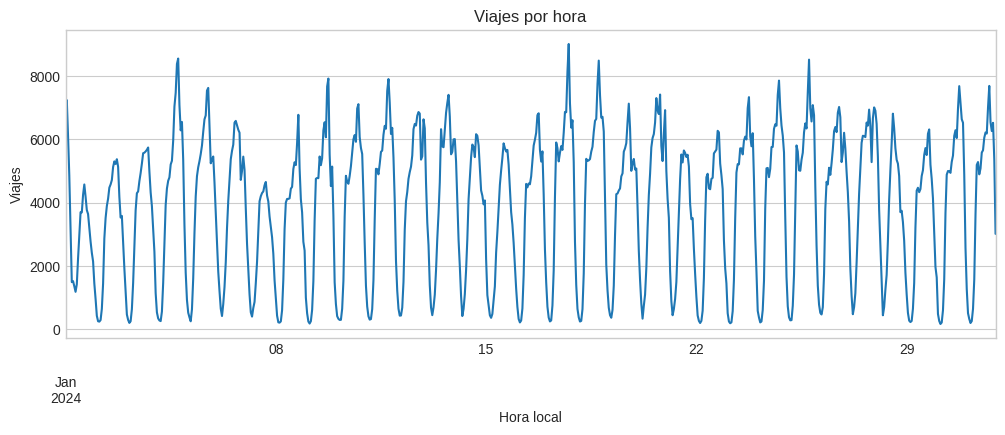

In [ ]:
viajes_por_hora = viajes_zonas.set_index("pickup_hora").resample("h").size()
ax = viajes_por_hora.plot(figsize=(12, 4), color="#1f77b4", linewidth=1.5)
ax.set(title="Viajes por hora", xlabel="Hora local", ylabel="Viajes")
plt.show()

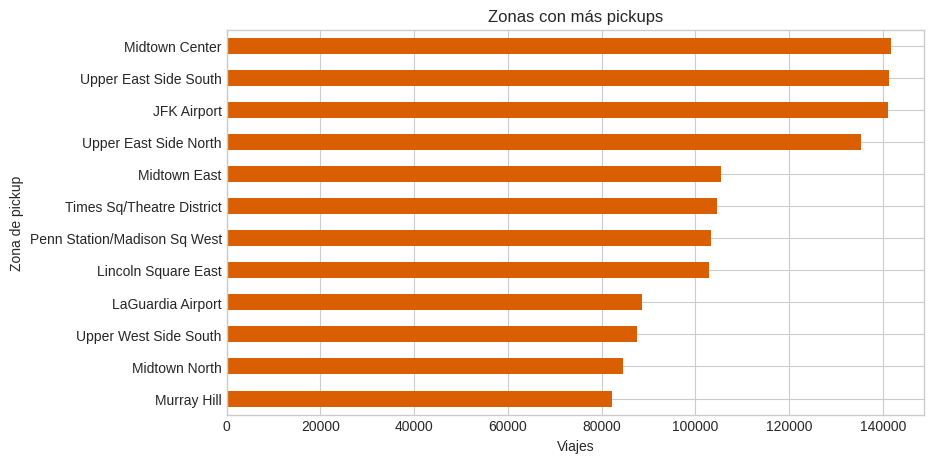

,pickups
pickup_zone,
Midtown Center,141714
Upper East Side South,141237
JFK Airport,141107
Upper East Side North,135303
Midtown East,105440
Times Sq/Theatre District,104590
Penn Station/Madison Sq West,103254
Lincoln Square East,102960
LaGuardia Airport,88556


In [ ]:
top_zonas = viajes_zonas["pickup_zone"].value_counts().head(12).sort_values()
ax = top_zonas.plot.barh(figsize=(9, 5), color="#d95f02")
ax.set(title="Zonas con más pickups", xlabel="Viajes", ylabel="Zona de pickup")
plt.show()
display(top_zonas.sort_values(ascending=False).rename("pickups").to_frame())

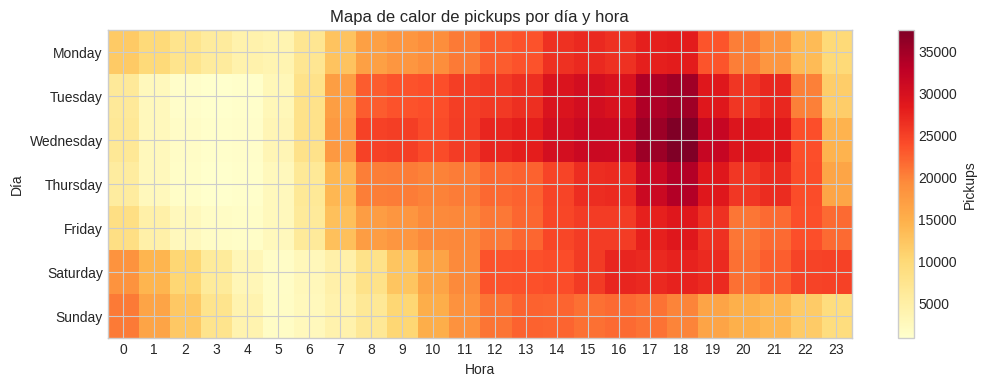

In [ ]:
patron = viajes_zonas.assign(
    dia=viajes_zonas["pickup_hora"].dt.day_name(),
    hora_dia=viajes_zonas["pickup_hora"].dt.hour,
).pivot_table(index="dia", columns="hora_dia", values="PULocationID", aggfunc="size", fill_value=0)
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
patron = patron.reindex([d for d in orden_dias if d in patron.index])
fig, ax = plt.subplots(figsize=(12, 4))
imagen = ax.imshow(patron, aspect="auto", cmap="YlOrRd")
ax.set(title="Mapa de calor de pickups por día y hora", xlabel="Hora", ylabel="Día")
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(patron.index)), labels=patron.index)
fig.colorbar(imagen, ax=ax, label="Pickups")
plt.show()

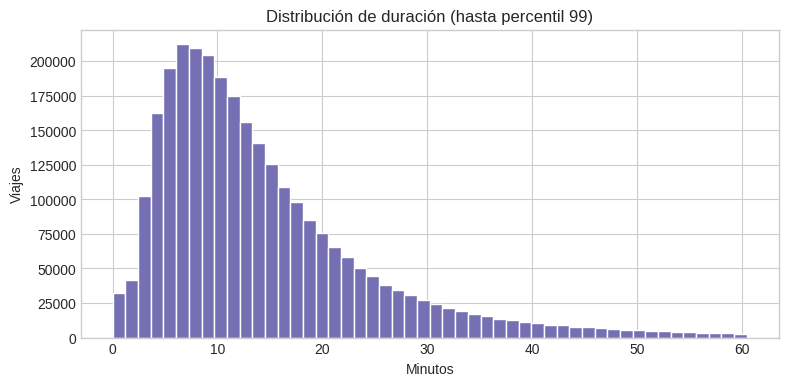

Percentil 99 mostrado: 60.5 minutos


In [ ]:
limite_99 = viajes_validos["duracion_min"].quantile(0.99)
ax = viajes_validos.loc[viajes_validos["duracion_min"] <= limite_99, "duracion_min"].plot.hist(
    bins=50, figsize=(9, 4), color="#7570b3", edgecolor="white"
)
ax.set(title="Distribución de duración (hasta percentil 99)", xlabel="Minutos", ylabel="Viajes")
plt.show()
print("Percentil 99 mostrado:", round(limite_99, 1), "minutos")

### 9.1. De zona-hora a una observación por hora

Para comparar la actividad total de taxis con el clima debemos volver de la unidad **zona-hora** a la unidad **hora**. En el ejemplo anterior:

```text
pickups = 20 + 35 + 15 = 70
temperatura = 5 °C
```

Por eso usamos operaciones diferentes:

- `sum` para `pickups`, porque cada zona aporta viajes distintos;
- `first` para temperatura y precipitación, porque cada fila contiene una copia del mismo clima horario.

Sumar la temperatura produciría `5 + 5 + 5 = 15 °C`, un valor sin interpretación física. El uso de `first` requiere comprobar antes que una misma hora no contenga valores climáticos diferentes entre zonas.

Consistencia climática por hora: OK


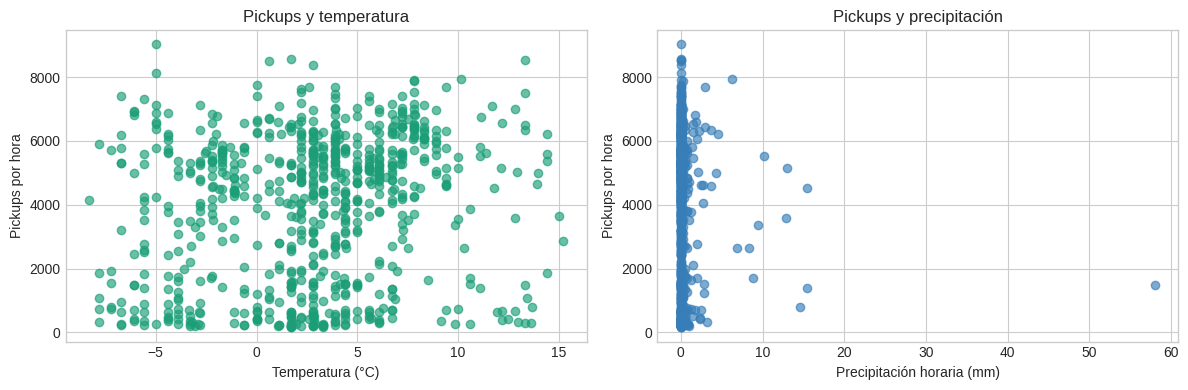

,pickups,temperatura_c,precipitacion_mm
pickups,1.000,0.158,-0.054
temperatura_c,0.158,1.000,0.193
precipitacion_mm,-0.054,0.193,1.000


In [ ]:
# Verificamos el supuesto necesario para conservar una sola copia con 'first'.
variables_clima_repetidas = ["temperatura_c", "precipitacion_mm"]
consistencia_clima = (
    zona_hora_clima
    .groupby("pickup_hora")[variables_clima_repetidas]
    .nunique(dropna=False)
)
assert consistencia_clima.le(1).all().all(), (
    "Una misma hora contiene valores climáticos diferentes entre zonas"
)
print("Consistencia climática por hora: OK")

# El clima está repetido por zona; volvemos a una observación por hora.
comparacion_horaria = (
    zona_hora_clima.groupby("pickup_hora", as_index=False)
    .agg(
        pickups=("pickups", "sum"),
        temperatura_c=("temperatura_c", "first"),
        precipitacion_mm=("precipitacion_mm", "first"),
    )
)
assert not comparacion_horaria["pickup_hora"].duplicated().any()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(comparacion_horaria["temperatura_c"], comparacion_horaria["pickups"], alpha=0.65, color="#1b9e77")
axes[0].set(xlabel="Temperatura (°C)", ylabel="Pickups por hora", title="Pickups y temperatura")
axes[1].scatter(comparacion_horaria["precipitacion_mm"], comparacion_horaria["pickups"], alpha=0.65, color="#377eb8")
axes[1].set(xlabel="Precipitación horaria (mm)", ylabel="Pickups por hora", title="Pickups y precipitación")
plt.tight_layout()
plt.show()
display(comparacion_horaria[["pickups", "temperatura_c", "precipitacion_mm"]].corr().round(3))

### Pregunta breve

¿Qué ocurriría si sumáramos la temperatura después de haberla replicado por zona?

<details><summary>Ver respuesta orientativa</summary>La misma observación se contabilizaría varias veces y produciría una temperatura sin interpretación física. Los pickups sí se suman porque cada zona aporta viajes diferentes; el clima se conserva una sola vez porque es el mismo valor replicado.</details>

### Ejercicio 3: interpretar sin exagerar

Escribe dos observaciones de los gráficos y una explicación alternativa. Evita frases causales como “la lluvia provoca...”.

**Tu respuesta:**

1. ...
2. ...
3. Explicación alternativa: ...

<details><summary>Ver pauta de solución</summary>Una respuesta sólida identifica dirección, magnitud o franjas horarias, menciona la ventana analizada y reconoce factores de confusión como hora pico, día de semana, aeropuerto, feriados o disponibilidad de taxis. Una correlación horaria no permite atribuir causalidad al clima.</details>

## 10. Exportar el producto fuera del repositorio

Antes de exportar comprobamos la clave, ordenamos el producto y usamos el directorio temporal del sistema. El nombre distingue el modo de clase del mes completo para no declarar una cobertura que no fue procesada.

In [ ]:
producto = zona_hora_clima.sort_values(["pickup_hora", "PULocationID"]).copy()
if producto.duplicated(["pickup_hora", "PULocationID"]).any():
    raise ValueError("La clave zona-hora no es única")

alcance = "primera_semana_enero_2024" if MODO_CLASE else "enero_2024"
ruta_producto = Path(tempfile.gettempdir()) / f"zona_hora_{alcance}.parquet"
producto.to_parquet(ruta_producto, index=False)
print("Producto temporal:", ruta_producto)
print("Unidad: zona de origen-hora local | Zona horaria:", ZONA_HORARIA)

Producto temporal: /tmp/zona_hora_enero_2024.parquet
Unidad: zona de origen-hora local | Zona horaria: America/New_York


## 11. Extensión espacial opcional

Esta celda descarga el ZIP del shapefile a un directorio temporal, extrae juntos sus componentes (`.shp`, `.dbf`, `.shx`, `.prj`) y construye un mapa Folium. La extracción explícita evita depender de que el backend geoespacial admita rutas virtuales `zip://`; al finalizar, el directorio temporal se elimina y no deja geometrías en el repositorio. Si `geopandas`, `folium` o `requests` no están instalados, informa exactamente cómo habilitar la sección y el resto del taller sigue siendo utilizable.

In [ ]:
try:
    import folium
    import geopandas as gpd
    import requests
    import zipfile
except ModuleNotFoundError as error:
    print(
        f"Sección espacial omitida: falta '{error.name}'. "
        "Descomenta `%pip install -q geopandas folium requests`, reinicia si es necesario y vuelve a ejecutar."
    )
else:
    with tempfile.TemporaryDirectory() as directorio_base:
        ruta_zip = Path(directorio_base) / "taxi_zones.zip"
        respuesta = requests.get(URL_GEOMETRIAS, timeout=60)
        respuesta.raise_for_status()
        ruta_zip.write_bytes(respuesta.content)
        if not zipfile.is_zipfile(ruta_zip):
            raise zipfile.BadZipFile("La descarga de zonas TLC no es un archivo ZIP válido")

        directorio_extraido = Path(directorio_base) / "taxi_zones_extraido"
        directorio_extraido.mkdir()
        with zipfile.ZipFile(ruta_zip) as archivo_zip:
            archivo_zip.extractall(directorio_extraido)

        archivos_shp = sorted(directorio_extraido.rglob("*.shp"))
        if not archivos_shp:
            raise FileNotFoundError("No se encontró un archivo .shp dentro del ZIP de zonas TLC")
        ruta_shp = next((ruta for ruta in archivos_shp if ruta.name == "taxi_zones.shp"), archivos_shp[0])
        geo_zonas = gpd.read_file(ruta_shp).to_crs(epsg=4326)

    pickups_mapa = viajes_zonas["PULocationID"].value_counts().rename("pickups").reset_index()
    geo_zonas["LocationID"] = pd.to_numeric(geo_zonas["LocationID"])
    geo_mapa = geo_zonas.merge(pickups_mapa, left_on="LocationID", right_on="PULocationID", how="left", validate="one_to_one")
    geo_mapa["pickups"] = geo_mapa["pickups"].fillna(0)
    min_x, min_y, max_x, max_y = geo_mapa.total_bounds
    centro = [(min_y + max_y) / 2, (min_x + max_x) / 2]
    mapa = folium.Map(location=centro, zoom_start=10, tiles="CartoDB positron")
    folium.Choropleth(
        geo_data=geo_mapa, data=geo_mapa, columns=["LocationID", "pickups"],
        key_on="feature.properties.LocationID", fill_color="YlOrRd",
        fill_opacity=0.7, line_opacity=0.3, legend_name="Pickups",
    ).add_to(mapa)
    folium.GeoJson(
        geo_mapa, style_function=lambda _: {"fillOpacity": 0, "weight": 0},
        tooltip=folium.GeoJsonTooltip(fields=["zone", "borough", "pickups"], aliases=["Zona", "Borough", "Pickups"]),
    ).add_to(mapa)
    display(mapa)

Output hidden; open in https://colab.research.google.com to view.

## 12. Conclusiones y límites

**Qué construimos**

- un proceso reproducible para enero de 2024, escalable de una semana al mes;
- una auditoría que hace visibles los criterios de exclusión;
- una tabla zona-hora enriquecida con clima mediante cardinalidad comprobada;
- visualizaciones temporales, espaciales y de asociación exploratoria.

**Límites que deben acompañar cualquier conclusión**

- Los registros son **viajes reportados de Yellow Taxi**, no demanda total, viajes no atendidos ni toda la movilidad de Nueva York.
- Una sola estación, `USW00094728`, no representa toda la variación meteorológica espacial de la ciudad.
- La cobertura y frecuencia de GHCNh pueden variar; resumir precipitación subhoraria exige revisar la documentación de medición.
- Las reglas de calidad y sus umbrales afectan los resultados y deben justificarse.
- La asociación entre pickups y clima está confundida por hora, día, localización, oferta, eventos y otros factores. **Correlación no implica causalidad.**
- `MODO_CLASE=True` describe solo la primera semana; para conclusiones mensuales se debe ejecutar el mes completo y evaluar estabilidad.

**Cierre:** ¿qué dato adicional pedirías para distinguir mejor demanda, oferta y viajes efectivamente realizados?

In [ ]:
producto.head()

,pickup_hora,PULocationID,pickup_borough,pickup_zone,pickups,hora,temperatura_c,humedad_relativa,viento,precipitacion_mm,visibilidad,observaciones
0,2024-01-01 00:00:00-05:00,4,Manhattan,Alphabet City,24,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1.0
1,2024-01-01 00:00:00-05:00,7,Queens,Astoria,4,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1.0
2,2024-01-01 00:00:00-05:00,9,Queens,Auburndale,1,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1.0
3,2024-01-01 00:00:00-05:00,10,Queens,Baisley Park,6,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1.0
4,2024-01-01 00:00:00-05:00,12,Manhattan,Battery Park,4,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1.0


# Trabajo práctico: exploración de dos variables
### **Estudiante:** Nuria Desteffani
## Declaración previa del análisis

### Par elegido

**Código:** PC-01

**Primera variable:** `pickups`

**Segunda variable:** `temperatura_c`

**Vista:** H — Horaria

### Pregunta exploratoria

¿Cómo varían los `pickups` por hora junto con la temperatura registrada durante enero de 2024?

### Significado de las variables

`pickups` representa la cantidad de viajes de Yellow Taxi registrados durante cada hora.

`temperatura_c` representa la temperatura registrada en grados Celsius durante cada hora. Los datos meteorológicos provienen de una estación de NOAA.

### Tipo de las variables

`pickups` es una variable numérica cuantitativa.

`temperatura_c` es una variable numérica cuantitativa continua.

### Unidad de análisis

La unidad de análisis es **una hora de enero de 2024**. Se utiliza la vista H, por lo que se trabaja con una fila por hora.

### Periodo y zona horaria

El análisis corresponde al período completo de enero de 2024, utilizando la zona horaria `America/New_York`.

### Población registrada y denominador

Se registraron 744 horas correspondientes al mes completo de enero de 2024.

Para el análisis bivariado se utilizan 743 horas, debido a que una hora presenta un valor faltante de `temperatura_c`.

### Afirmaciones que los datos no permiten

Los datos permiten describir cómo se distribuyen los pickups y la temperatura y estudiar su asociación durante el período analizado.

No permiten afirmar que la temperatura cause cambios en la cantidad de pickups. Tampoco representan la demanda total de viajes ni las solicitudes que no fueron atendidas.

In [ ]:
producto.groupby("pickup_hora")["temperatura_c"].nunique().value_counts()

,count
temperatura_c,
1,743
0,1


In [ ]:
por_hora = producto.groupby("pickup_hora", as_index=False).agg(
    pickups=("pickups", "sum"),
    temperatura_c=("temperatura_c", "first"),
    humedad_relativa=("humedad_relativa", "first"),
    viento=("viento", "first"),
    visibilidad=("visibilidad", "first"),
)

por_hora.head()

,pickup_hora,pickups,temperatura_c,humedad_relativa,viento,visibilidad
0,2024-01-01 00:00:00-05:00,6513,5.6,55.0,3.1,16.093
1,2024-01-01 01:00:00-05:00,7249,5.6,58.0,2.1,16.093
2,2024-01-01 02:00:00-05:00,6111,5.0,60.0,0.0,16.093
3,2024-01-01 03:00:00-05:00,4857,5.0,62.0,1.5,16.093
4,2024-01-01 04:00:00-05:00,3128,4.4,68.0,0.0,16.093


In [ ]:
print("Cantidad de horas:", len(por_hora))
print("Primera hora:", por_hora["pickup_hora"].min())
print("Última hora:", por_hora["pickup_hora"].max())

Cantidad de horas: 744
Primera hora: 2024-01-01 00:00:00-05:00
Última hora: 2024-01-31 23:00:00-05:00


## 1. Exploración individual de `pickups`

La variable `pickups` representa la cantidad de viajes de Yellow Taxi registrados durante cada hora.

En la vista H, los datos se reducen a una fila por hora. Para obtener los pickups horarios se suman los pickups de las distintas zonas correspondientes a cada hora, ya que cada zona aporta viajes distintos.

### 1.1 Descripción y cobertura

Se analizaron 744 horas correspondientes al mes completo de enero de 2024.

La variable `pickups` presenta 744 valores válidos, sin datos faltantes ni valores iguales a cero.

Los valores varían entre 152 y 9027 pickups por hora. La media es de 3932,93 pickups por hora, mientras que la mediana es de 4519 pickups por hora.

El 50 % central de las observaciones se encuentra entre 1592,25 y 5719,25 pickups por hora.

La diferencia entre la media y la mediana, junto con la distribución observada posteriormente en el histograma, muestra que la variable presenta una distribución con bastante variabilidad entre las horas.

In [ ]:
print("Filas totales:", len(por_hora))
print("Valores válidos:", por_hora["pickups"].notna().sum())
print("Valores faltantes:", por_hora["pickups"].isna().sum())
print("Valores cero:", (por_hora["pickups"] == 0).sum())

por_hora["pickups"].describe()

Filas totales: 744
Valores válidos: 744
Valores faltantes: 0
Valores cero: 0


,pickups
count,744.000000
mean,3932.931452
std,2275.767808
min,152.000000
25%,1592.250000
50%,4519.000000
75%,5719.250000
max,9027.000000


### 1.2 Valores potencialmente anómalos

Para identificar posibles valores extremos se utilizó la regla de Tukey, considerando como candidatos los valores inferiores a Q1 - 1,5 × IQR o superiores a Q3 + 1,5 × IQR.

In [ ]:
Q1 = por_hora["pickups"].quantile(0.25)
Q3 = por_hora["pickups"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 1592.25
Q3: 5719.25
IQR: 4127.0
Límite inferior: -4598.25
Límite superior: 11909.75


Para `pickups` se obtuvieron los siguientes valores:

- Q1 = 1592,25
- Q3 = 5719,25
- IQR = 4127
- Límite inferior = -4598,25
- Límite superior = 11909,75

Los valores observados se encuentran entre 152 y 9027 pickups por hora. Por lo tanto, no se identificaron casos potencialmente anómalos mediante esta regla.

Esto no significa que no existan horas inusuales, sino que ninguna fue señalada como potencialmente anómala por el criterio estadístico utilizado.

### 1.3 Distribución de `pickups`

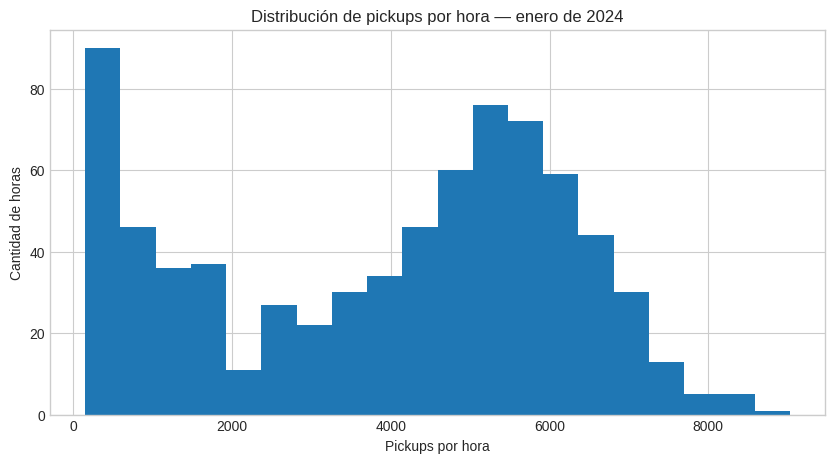

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    por_hora["pickups"],
    bins=20
)

plt.title("Distribución de pickups por hora — enero de 2024")
plt.xlabel("Pickups por hora")
plt.ylabel("Cantidad de horas")

plt.show()

El histograma se construyó utilizando 20 intervalos (bins), buscando un equilibrio entre nivel de detalle y facilidad de interpretación.

Se observa una distribución con una concentración importante de horas en valores bajos y otro grupo importante de observaciones aproximadamente entre 4000 y 6500 pickups por hora. También aparecen algunas horas con valores cercanos a 8000 y 9000 pickups.

El histograma permite observar la variabilidad de los pickups entre las distintas horas y la forma general de la distribución.

### 1.4 Boxplot de `pickups`

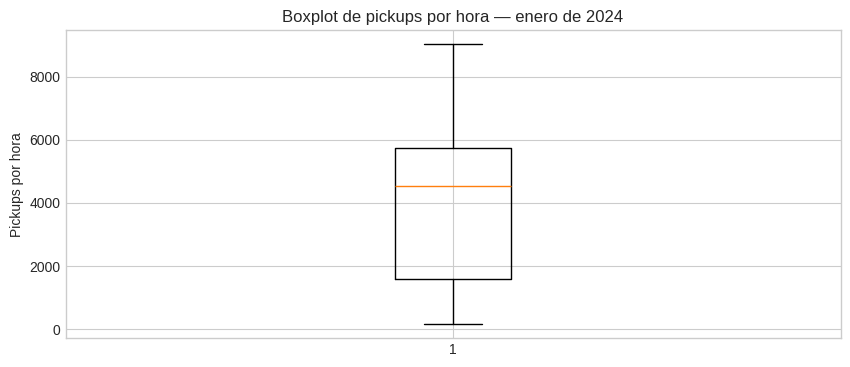

In [35]:
plt.figure(figsize=(10, 4))

plt.boxplot(por_hora["pickups"])

plt.title("Boxplot de pickups por hora — enero de 2024")
plt.ylabel("Pickups por hora")

plt.show()

El boxplot muestra una mediana de 4519 pickups por hora. El 50 % central de las observaciones se encuentra entre 1592,25 y 5719,25 pickups por hora, correspondientes al primer y tercer cuartil.

No se observan puntos aislados fuera de los bigotes, lo que es consistente con el resultado obtenido mediante la regla de Tukey, que no identificó casos potencialmente anómalos.

El bigote superior es más extenso que el inferior, lo que refleja una mayor extensión de los valores hacia el extremo superior de la distribución.

El boxplot complementa al histograma al permitir visualizar de forma directa la mediana, los cuartiles y la dispersión de los pickups por hora.

## 2. Exploración individual de `temperatura_c`

La variable `temperatura_c` representa la temperatura registrada en grados Celsius durante cada hora. Los datos meteorológicos provienen de una estación de NOAA.

En la vista H se conserva una única observación meteorológica por hora, después de verificar que no hubiera más de un valor distinto de temperatura dentro de una misma hora.

### 2.1 Descripción y cobertura

Se analizaron 744 horas.

Se obtuvieron 743 valores válidos y 1 valor faltante.

La temperatura presenta valores entre -8,3 °C y 15,2 °C. La media es de 2,74 °C y la mediana es de 2,8 °C.

El 50 % central de las temperaturas se encuentra entre -0,6 °C y 6,1 °C.

Se registraron 18 valores iguales a 0 °C. Estos valores se consideran mediciones válidas de temperatura y no deben confundirse con datos faltantes.

El único valor faltante representa una ausencia de medición y se mantiene como faltante.

In [36]:
print("Filas totales:", len(por_hora))
print("Valores válidos:", por_hora["temperatura_c"].notna().sum())
print("Valores faltantes:", por_hora["temperatura_c"].isna().sum())
print("Valores cero:", (por_hora["temperatura_c"] == 0).sum())

por_hora["temperatura_c"].describe()

Filas totales: 744
Valores válidos: 743
Valores faltantes: 1
Valores cero: 18


,temperatura_c
count,743.000000
mean,2.735884
std,4.762700
min,-8.300000
25%,-0.600000
50%,2.800000
75%,6.100000
max,15.200000


### 2.2 Valores potencialmente anómalos

Para identificar posibles valores extremos se utilizó la regla de Tukey.

In [37]:
Q1_temp = por_hora["temperatura_c"].quantile(0.25)
Q3_temp = por_hora["temperatura_c"].quantile(0.75)

IQR_temp = Q3_temp - Q1_temp

limite_inferior_temp = Q1_temp - 1.5 * IQR_temp
limite_superior_temp = Q3_temp + 1.5 * IQR_temp

print("Q1:", Q1_temp)
print("Q3:", Q3_temp)
print("IQR:", IQR_temp)
print("Límite inferior:", limite_inferior_temp)
print("Límite superior:", limite_superior_temp)

Q1: -0.6
Q3: 6.1
IQR: 6.699999999999999
Límite inferior: -10.649999999999999
Límite superior: 16.15


Para `temperatura_c` se obtuvieron los siguientes valores:

- Q1 = -0,6 °C
- Q3 = 6,1 °C
- IQR = 6,7 °C
- Límite inferior = -10,65 °C
- Límite superior = 16,15 °C

El valor mínimo observado es -8,3 °C y el máximo es 15,2 °C. Ambos se encuentran dentro de los límites calculados.

Por lo tanto, no se identificaron casos potencialmente anómalos mediante esta regla.

El único valor faltante no se considera un caso anómalo, sino una ausencia de medición.

In [38]:
casos_anomalos_temp = por_hora[
    (por_hora["temperatura_c"] < limite_inferior_temp) |
    (por_hora["temperatura_c"] > limite_superior_temp)
]

print("Casos potencialmente anómalos:", len(casos_anomalos_temp))

Casos potencialmente anómalos: 0


### 2.3 Distribución de `temperatura_c`

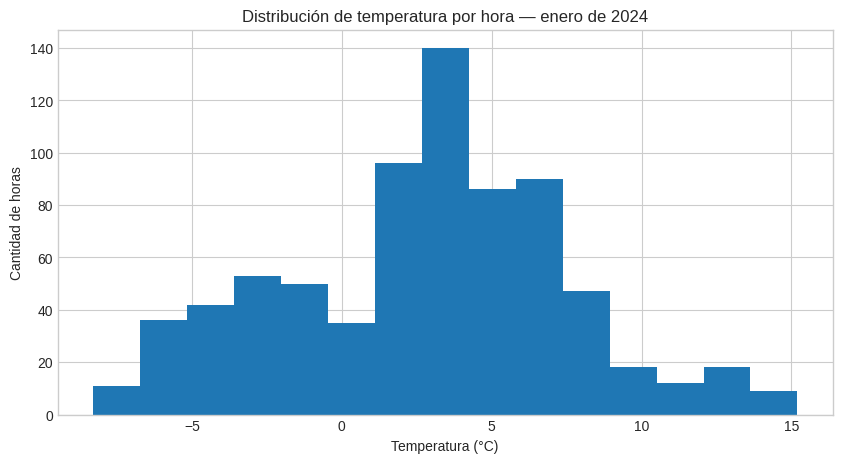

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(
    por_hora["temperatura_c"].dropna(),
    bins=15
)

plt.title("Distribución de temperatura por hora — enero de 2024")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Cantidad de horas")

plt.show()

El histograma se construyó utilizando 15 intervalos (bins), una resolución que permite observar con suficiente detalle la distribución de las temperaturas sin generar una fragmentación excesiva.

La mayor concentración de observaciones se encuentra aproximadamente entre 1 °C y 8 °C, con mayor frecuencia alrededor de 2 °C a 5 °C.

También se observan temperaturas negativas y algunas superiores a 10 °C. La distribución presenta variabilidad y no es completamente simétrica.

El histograma se construyó utilizando únicamente las 743 observaciones con temperatura disponible; el valor faltante no se representa en el gráfico.

### 2.4 Boxplot de `temperatura_c`

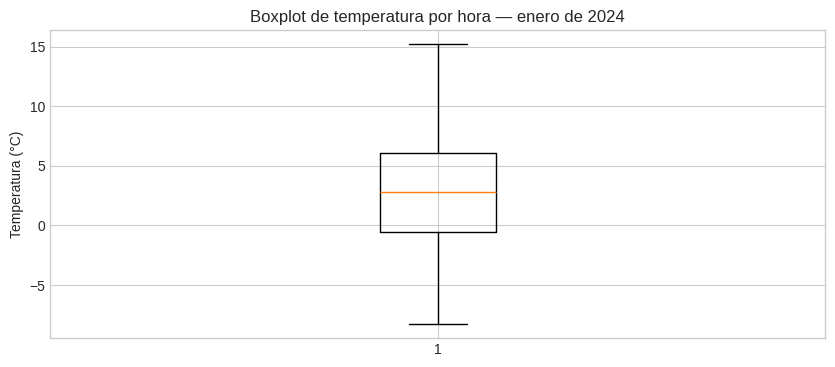

In [40]:
plt.figure(figsize=(10, 4))

plt.boxplot(por_hora["temperatura_c"].dropna())

plt.title("Boxplot de temperatura por hora — enero de 2024")
plt.ylabel("Temperatura (°C)")

plt.show()

El boxplot muestra una mediana de 2,8 °C. El 50 % central de las temperaturas se encuentra entre -0,6 °C y 6,1 °C, valores correspondientes al primer y tercer cuartil.

La distribución presenta dispersión hacia ambos extremos, desde temperaturas negativas hasta valores superiores a 10 °C. No se observan puntos aislados fuera de los bigotes, lo que coincide con el resultado obtenido mediante la regla de Tukey, que no identificó casos potencialmente anómalos.

El boxplot complementa al histograma porque permite visualizar directamente la mediana, los cuartiles y la dispersión de las temperaturas durante las horas con medición disponible.

## 3. Relación entre `pickups` y `temperatura_c`

Se analiza la relación entre la cantidad de pickups por hora y la temperatura
registrada en esa misma hora. La unidad de análisis es la hora y se trabaja con las observaciones que tienen valores válidos para ambas variables.

Como existe un valor faltante en `temperatura_c`, el análisis bivariado se realiza sobre 743 observaciones válidas.

### 3.1 Diagrama de dispersión

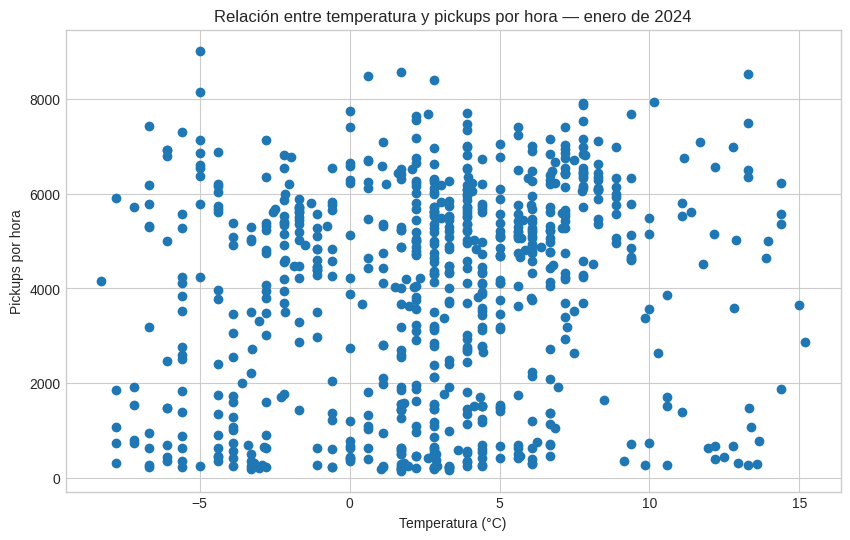

In [41]:
datos_bivariados = por_hora[["pickups", "temperatura_c"]].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    datos_bivariados["temperatura_c"],
    datos_bivariados["pickups"]
)

plt.title("Relación entre temperatura y pickups por hora — enero de 2024")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Pickups por hora")

plt.show()

El diagrama de dispersión muestra una gran variabilidad en la cantidad de pickups para una misma temperatura. Se observa que, a medida que aumentan las temperaturas, aparecen con mayor frecuencia valores altos de pickups, especialmente entre aproximadamente 5 °C y 10 °C. Sin embargo, también se presentan valores bajos de pickups a temperaturas relativamente altas.

Por lo tanto, visualmente se aprecia una posible asociación positiva, pero con una dispersión considerable y sin una relación lineal fuerte y claramente definida. También se observan concentraciones de puntos y valores de temperatura repetidos, representados como bandas verticales.

El gráfico permite explorar la forma de la relación y detectar posibles agrupamientos antes de calcular medidas de asociación. La presencia de una asociación visual no permite afirmar que la temperatura cause cambios en la cantidad de pickups, ya que pueden intervenir otros factores como la hora del día, el día de la semana, feriados o la disponibilidad de taxis.

### 3.2 Correlación de Pearson y Spearman

Se calcularon los coeficientes de correlación de Pearson y Spearman sobre las
743 observaciones horarias que presentan valores válidos en ambas variables.

Pearson permite evaluar la asociación lineal, mientras que Spearman evalúa la
asociación monotónica a partir del orden de los valores.

La comparación entre ambos coeficientes se utilizará posteriormente como parte del análisis de sensibilidad.

In [42]:
pearson = datos_bivariados["pickups"].corr(
    datos_bivariados["temperatura_c"],
    method="pearson"
)

spearman = datos_bivariados["pickups"].corr(
    datos_bivariados["temperatura_c"],
    method="spearman"
)

print("Correlación de Pearson:", pearson)
print("Correlación de Spearman:", spearman)

Correlación de Pearson: 0.15827738516763645
Correlación de Spearman: 0.18425094955070606


## 4. Análisis de sensibilidad

La correlación de Pearson entre `pickups` y `temperatura_c` es 0,1583,
mientras que la correlación de Spearman es 0,1843.

Ambos coeficientes son positivos y de magnitud baja, por lo que indican una
asociación positiva débil entre la temperatura y la cantidad de pickups por
hora. Esto significa que, en general, las horas con temperaturas más altas
tienden a presentar algo más de pickups, aunque la relación es poco marcada y
existe una importante dispersión.

El coeficiente de Spearman es ligeramente mayor que el de Pearson, pero la
diferencia es pequeña. Por lo tanto, la conclusión general sobre la intensidad
y dirección de la asociación no cambia al utilizar una medida basada en rangos.

Estos resultados describen asociación y no permiten afirmar que la temperatura
sea la causa de los cambios en la cantidad de pickups. La relación puede estar
influida por otras variables, especialmente la hora del día y el día de la
semana.

## 5. Hallazgos finales

### Hallazgo 1 — `pickups`

Durante enero de 2024 se analizaron 744 horas y se obtuvieron 744 valores válidos de `pickups`.

La cantidad de pickups por hora presentó valores entre 152 y 9027, con una mediana de 4519 pickups por hora. El histograma y el boxplot muestran una distribución con una dispersión considerable entre las distintas horas.

La regla de Tukey no identificó casos potencialmente anómalos.

Este resultado describe únicamente los viajes de Yellow Taxi registrados y no representa la demanda total de taxis, ya que no incluye solicitudes que no fueron atendidas.

Como siguiente comprobación, sería posible estudiar la distribución de `pickups` separando las horas según hora del día y día de la semana para identificar posibles patrones temporales.

### Hallazgo 2 — `temperatura_c`

Durante las mismas 744 horas de enero de 2024 se registraron 743 valores válidos de temperatura y un valor faltante.

Las temperaturas observadas estuvieron entre -8,3 °C y 15,2 °C, con una mediana de 2,8 °C. El histograma muestra una mayor concentración de observaciones aproximadamente entre 1 °C y 8 °C.

Se registraron 18 valores iguales a 0 °C, considerados mediciones válidas, y no se identificaron casos potencialmente anómalos mediante la regla de Tukey.

El valor faltante limita el análisis bivariado a 743 horas.

Como siguiente comprobación, sería posible analizar la evolución de la temperatura a lo largo de las horas y comparar su comportamiento entre distintos días.

### Hallazgo 2 — `temperatura_c`

Durante las mismas 744 horas de enero de 2024 se registraron 743 valores válidos de temperatura y un valor faltante.

Las temperaturas observadas estuvieron entre -8,3 °C y 15,2 °C, con una mediana de 2,8 °C. El histograma muestra una mayor concentración de observaciones aproximadamente entre 1 °C y 8 °C.

Se registraron 18 valores iguales a 0 °C, considerados mediciones válidas, y no se identificaron casos potencialmente anómalos mediante la regla de Tukey.

El valor faltante limita el análisis bivariado a 743 horas.

Como siguiente comprobación, sería posible analizar la evolución de la temperatura a lo largo de las horas y comparar su comportamiento entre distintos días.

## 6. Conclusión general

El análisis del par PC-01 permitió describir el comportamiento de `pickups` y `temperatura_c` durante enero de 2024 y estudiar su asociación a nivel horario.

`pickups` mostró una variabilidad considerable entre las horas, mientras que `temperatura_c` presentó valores entre -8,3 °C y 15,2 °C, con un único valor faltante.

No se identificaron casos potencialmente anómalos en ninguna de las dos variables mediante la regla de Tukey.

La relación entre ambas variables mostró una asociación positiva de magnitud baja. Pearson presentó un valor de 0,1583 y Spearman de 0,1843, por lo que la conclusión general se mantuvo al utilizar ambos métodos.

Estos resultados deben interpretarse como descriptivos y no como evidencia de causalidad. La relación puede estar condicionada por otros factores que no fueron controlados en este análisis, especialmente aquellos relacionados con el tiempo, como la hora del día y el día de la semana.

Por lo tanto, el análisis permite describir una asociación positiva débil entre temperatura y pickups durante enero de 2024, pero no permite afirmar que la temperatura por sí sola explique los cambios observados en la cantidad de pickups.